In [10]:
# 4.1 Import Library dan Konfigurasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import (mean_absolute_error, mean_squared_error, 
                             f1_score, accuracy_score, confusion_matrix, 
                             classification_report, precision_score, recall_score)

# Konfigurasi Visualisasi 
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['font.size'] = 12

# Path File
MODEL_FILE = '../../outputs/SLA/sla_sentiment_clean_with_ignore.csv'
GT_FILE = '../../outputs/evaluation/ground_truth_final.csv'
OUTPUT_DIR = '../../outputs/evaluation'

print(f"[INFO] Library dimuat. Konfigurasi evaluasi siap.")

[INFO] Library dimuat. Konfigurasi evaluasi siap.


In [11]:
# 4.2 Load Data
# Load Ground Truth
df_gt = pd.read_csv(GT_FILE)
# Load Hasil Model (Prediksi)
df_model = pd.read_csv(MODEL_FILE)

# Merge berdasarkan ID 'no'
df_eval = pd.merge(
    df_gt[['no', 'ground_truth_scaled']],
    df_model[['no', 'compound_score']],
    on='no',
    how='inner'
).dropna()

print(f"[INFO] Dataset evaluasi berhasil digabung: {len(df_eval)} data.")
print(f"   - Range Model (Compound): {df_eval['compound_score'].min():.4f} s.d {df_eval['compound_score'].max():.4f}")
print(f"   - Range Human (Scaled):   {df_eval['ground_truth_scaled'].min():.4f} s.d {df_eval['ground_truth_scaled'].max():.4f}")

[INFO] Dataset evaluasi berhasil digabung: 450 data.
   - Range Model (Compound): -0.9833 s.d 0.9934
   - Range Human (Scaled):   -1.0000 s.d 0.4000


In [12]:
# 4.3 Ekstrak Skor untuk Evaluasi
df_eval['human_visual_score'] = df_eval['ground_truth_scaled'] * 4

# Definisi Variabel untuk Evaluasi Continuous
y_true_scaled = df_eval['ground_truth_scaled']
y_pred_scaled = df_eval['compound_score']

# Definisi Variabel untuk Visualisasi Scatter Plot
y_human_visual = df_eval['human_visual_score']
y_model_pred = df_eval['compound_score']

print("[INFO] Persiapan skala visualisasi selesai.")
print("   Sumbu Y (Human) akan dirender di range -4 s.d +4.")

[INFO] Persiapan skala visualisasi selesai.
   Sumbu Y (Human) akan dirender di range -4 s.d +4.


In [13]:
# 4.4 Hitung Pearson dan Spearman (Linear dan Monotonic Relationship)
pearson_r, p_val = pearsonr(y_true_scaled, y_pred_scaled)
spearman_rho, p_val_s = spearmanr(y_true_scaled, y_pred_scaled)

# Hitung Error Metrics (Sesuai standar evaluasi VADER)
rmse = np.sqrt(mean_squared_error(y_true_scaled, y_pred_scaled))
mae = mean_absolute_error(y_true_scaled, y_pred_scaled)
r2 = np.corrcoef(y_true_scaled, y_pred_scaled)[0, 1]**2 

print("HASIL EVALUASI CONTINUOUS SCORE (SLA)")
print(f"Pearson Correlation (r)    : {pearson_r:.4f} (Target VADER: 0.88)")
print(f"Spearman Rank (rho)        : {spearman_rho:.4f}")
print(f"RMSE (Root Mean Sq. Error) : {rmse:.4f}")
print(f"MAE (Mean Abs. Error)      : {mae:.4f}")
print(f"R-Squared (R²)             : {r2:.4f}")

HASIL EVALUASI CONTINUOUS SCORE (SLA)
Pearson Correlation (r)    : 0.2688 (Target VADER: 0.88)
Spearman Rank (rho)        : 0.2795
RMSE (Root Mean Sq. Error) : 0.7312
MAE (Mean Abs. Error)      : 0.6279
R-Squared (R²)             : 0.0722


In [14]:
# 4.5 Evaluasi Kategorikal dengan Threshold ±0.05
def categorize(score):
    if score > 0.05: return 'positive'
    elif score < -0.05: return 'negative'
    else: return 'neutral'

# Terapkan ke Model dan Ground Truth
df_eval['pred_class'] = df_eval['compound_score'].apply(categorize)
df_eval['gt_class'] = df_eval['ground_truth_scaled'].apply(categorize)

labels = ['negative', 'neutral', 'positive']

# Hitung Metrik Klasifikasi (Sesuai paper VADER)
acc = accuracy_score(df_eval['gt_class'], df_eval['pred_class'])
f1_macro = f1_score(df_eval['gt_class'], df_eval['pred_class'], average='macro', labels=labels)

print("HASIL EVALUASI KLASIFIKASI (SLA)")
print(f"Accuracy        : {acc:.4f}")
print(f"F1-Score (Macro): {f1_macro:.4f}")
print("-"*50)
print("Classification Report:")
print(classification_report(df_eval['gt_class'], df_eval['pred_class'],
                            target_names=labels, zero_division=0))

HASIL EVALUASI KLASIFIKASI (SLA)
Accuracy        : 0.3956
F1-Score (Macro): 0.3619
--------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

    negative       0.49      0.48      0.48       153
     neutral       0.42      0.09      0.15       164
    positive       0.34      0.68      0.45       133

    accuracy                           0.40       450
   macro avg       0.42      0.42      0.36       450
weighted avg       0.42      0.40      0.35       450



In [17]:
# 4.6 Tabel Metrik Utama
acc = accuracy_score(df_eval['gt_class'], df_eval['pred_class'])
prec = precision_score(df_eval['gt_class'], df_eval['pred_class'], average='macro', zero_division=0)
rec = recall_score(df_eval['gt_class'], df_eval['pred_class'], average='macro', zero_division=0)
f1 = f1_score(df_eval['gt_class'], df_eval['pred_class'], average='macro', zero_division=0)

metrics_df = pd.DataFrame([{
    'Konfigurasi': 'SLA + Ignore Function',
    'Accuracy': f"{acc:.4f}",
    'Precision (M)': f"{prec:.4f}",
    'Recall (M)': f"{rec:.4f}",
    'F1-Score (M)': f"{f1:.4f}"
}])

metrics_df

,Konfigurasi,Accuracy,Precision (M),Recall (M),F1-Score (M)
0,SLA + Ignore Function,0.3956,0.4154,0.4151,0.3619


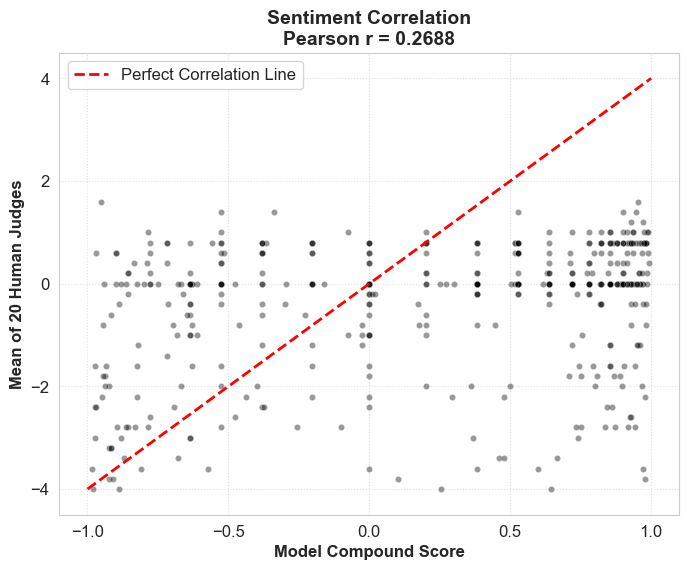

[INFO] Scatter plot tersimpan.


In [18]:
# 4.7 Visualisasi: Scatter Plot dan Regression Line
plt.figure(figsize=(8, 6))

# Scatter Plot: X = Model (-1,1), Y = Human (-4,4)
sns.scatterplot(x=y_model_pred, y=y_human_visual, alpha=0.4, color='black', s=20)

# Garis Merah: Garis regresi ideal (y = x * 4)
x_vals = np.linspace(-1, 1, 100)
y_vals = x_vals * 4
plt.plot(x_vals, y_vals, color='red', linestyle='--', linewidth=2, label='Perfect Correlation Line')

# Konfigurasi Sumbu
plt.xlim(-1.1, 1.1)
plt.ylim(-4.5, 4.5)
plt.xticks(np.arange(-1, 1.1, 0.5))
plt.yticks(np.arange(-4, 5, 2))

plt.xlabel('Model Compound Score', fontsize=12, fontweight='bold')
plt.ylabel('Mean of 20 Human Judges', fontsize=12, fontweight='bold')
plt.title(f'Sentiment Correlation\nPearson r = {pearson_r:.4f}', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.savefig(f'{OUTPUT_DIR}/scatter_plot_SLA_Ignore.png', dpi=300, bbox_inches='tight')
plt.show()

print("[INFO] Scatter plot tersimpan.")

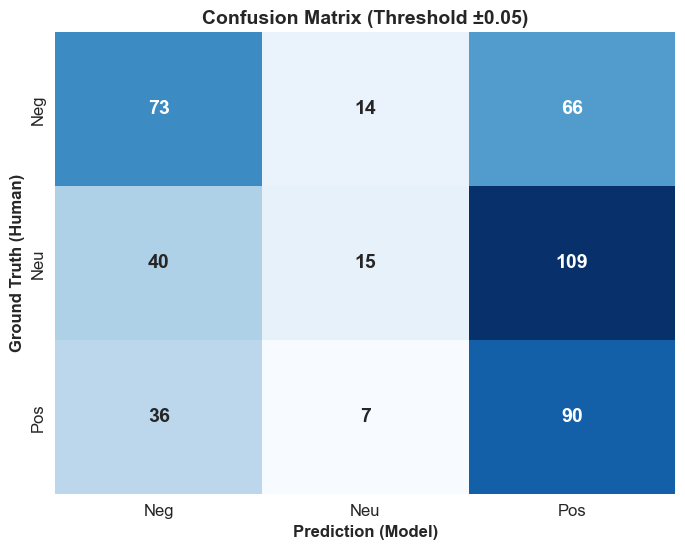

[INFO] Confusion matrix tersimpan.
[INFO] Proses evaluasi selesai!


In [19]:
# 4.8 Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))

# Hitung Confusion Matrix
cm = confusion_matrix(df_eval['gt_class'], df_eval['pred_class'], labels=labels)

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Neg', 'Neu', 'Pos'], 
            yticklabels=['Neg', 'Neu', 'Pos'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Confusion Matrix (Threshold ±0.05)', fontsize=14, fontweight='bold')
plt.ylabel('Ground Truth (Human)', fontsize=12, fontweight='bold')
plt.xlabel('Prediction (Model)', fontsize=12, fontweight='bold')

plt.savefig(f'{OUTPUT_DIR}/confusion_matrix_SLA_Ignore.png', dpi=300, bbox_inches='tight')
plt.show()

print("[INFO] Confusion matrix tersimpan.")
print("[INFO] Proses evaluasi selesai!")

In [20]:
# 4.9 Simpan Hasil dan Catatan Penulisan
eval_summary = {
    'konfigurasi': 'SLA + Ignore Function',
    'dataset_size': len(df_eval),
    'ground_truth_distribution': df_eval['gt_class'].value_counts().to_dict(),
    'metrics': metrics_df.iloc[0].to_dict()
}

summary_path = os.path.join(OUTPUT_DIR, 'evaluation_summary_SLA_ignore.json')
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(eval_summary, f, indent=2, ensure_ascii=False)

metrics_path = os.path.join(OUTPUT_DIR, 'evaluation_metrics_SLA_ignore.csv')
metrics_df.to_csv(metrics_path, index=False)

print(f"\n[INFO] Hasil evaluasi tersimpan di: {OUTPUT_DIR}/")
print(f"   - Summary: {summary_path}")
print(f"   - Metrics: {metrics_path}")

print("\n[CATATAN UNTUK BAB 4]")
print(f"1. Dataset evaluasi: {len(df_eval)} tweet terlabel manual")
print(f"2. Konfigurasi: SLA + Ignore Function")
# Mengambil f1 dari variabel f1 yang sudah dihitung di cell 4.6
print(f"3. F1-Score Macro: {f1:.4f} | Accuracy: {acc:.4f}")


[INFO] Hasil evaluasi tersimpan di: ../../outputs/evaluation/
   - Summary: ../../outputs/evaluation\evaluation_summary_SLA_ignore.json
   - Metrics: ../../outputs/evaluation\evaluation_metrics_SLA_ignore.csv

[CATATAN UNTUK BAB 4]
1. Dataset evaluasi: 450 tweet terlabel manual
2. Konfigurasi: SLA + Ignore Function
3. F1-Score Macro: 0.3619 | Accuracy: 0.3956
